In [1]:
# Dutch BESS Market & Commercial Optimization
# Notebook 3 — BESS Valuation & Revenue Stacking
#
# Purpose:
# Translate optimized operational value into a simplified
# unlevered project valuation.
#
# Scope:
# - wholesale arbitrage benchmark
# - balancing revenue scenario
# - throughput/degradation
# - CAPEX and fixed O&M
# - NPV, IRR and payback
# - commercial scenarios and sensitivities
#
# Important:
# Historical perfect-foresight optimization is treated as a
# benchmark of market opportunity, not as a real-time trading forecast.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("Imports successful.")

Imports successful.


In [3]:
PROJECT_DIR = Path("..").resolve()

DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = PROJECT_DIR / "figures"

FULL_RESULTS_FILE = RESULTS_DIR / "monthly_bess_arbitrage_full_history.csv"
SCENARIO_RESULTS_FILE = RESULTS_DIR / "monthly_bess_arbitrage_scenarios.csv"

print("Project directory:", PROJECT_DIR)
print("Full optimization results:", FULL_RESULTS_FILE)
print("Results directory:", RESULTS_DIR)

Project directory: C:\Users\USER\dutch-bess-market-commercial-optimization
Full optimization results: C:\Users\USER\dutch-bess-market-commercial-optimization\results\monthly_bess_arbitrage_full_history.csv
Results directory: C:\Users\USER\dutch-bess-market-commercial-optimization\results


In [4]:
monthly_results = pd.read_csv(
    FULL_RESULTS_FILE,
    index_col="month"
)

monthly_results.index = pd.PeriodIndex(
    monthly_results.index,
    freq="M"
)

display(monthly_results.round(2))

,intervals,total_revenue_eur,charging_cost_eur,discharge_revenue_eur,energy_charged_mwh,energy_discharged_mwh,efc,max_daily_discharge_mwh,max_soc_mwh,min_soc_mwh
month,,,,,,,,,,
2025-10,2980,308441.64,168824.60,477266.24,3444.44,3100.00,31.00,100.0,90.0,10.0
2025-11,2880,194109.58,224896.65,419006.23,3333.33,3000.00,30.00,100.0,90.0,10.0
2025-12,2976,136921.14,223994.01,360915.15,3444.44,3100.00,31.00,100.0,90.0,10.0
2026-01,2976,167294.58,288462.38,455756.96,3427.25,3084.53,30.85,100.0,90.0,10.0
2026-02,2688,142498.32,211736.72,354235.04,3111.11,2800.00,28.00,100.0,90.0,10.0
2026-03,2972,418588.15,123275.37,541863.52,3444.44,3100.00,31.00,100.0,90.0,10.0
2026-04,2880,466271.39,24327.02,490598.41,3333.33,3000.00,30.00,100.0,90.0,10.0
2026-05,2976,442742.22,69839.02,512581.24,3444.44,3100.00,31.00,100.0,90.0,10.0
2026-06,2880,531040.24,146501.93,677542.18,3333.33,3000.00,30.00,100.0,90.0,10.0


In [5]:
POWER_MW = 50.0
ENERGY_MWH = 100.0

MIN_SOC_MWH = 10.0
MAX_SOC_MWH = 90.0

ROUND_TRIP_EFFICIENCY = 0.90
AVAILABILITY = 0.97

LIFETIME_YEARS = 15
DISCOUNT_RATE = 0.08

CAPEX_EUR_PER_KWH = 200.0
FIXED_OM_EUR_PER_KWH_YEAR = 6.0

print("BESS technical assumptions")
print("=" * 50)
print(f"Power:                  {POWER_MW:.0f} MW")
print(f"Energy:                 {ENERGY_MWH:.0f} MWh")
print(f"Usable SOC:             {MIN_SOC_MWH:.0f}–{MAX_SOC_MWH:.0f} MWh")
print(f"Round-trip efficiency:  {ROUND_TRIP_EFFICIENCY:.0%}")
print(f"Availability:           {AVAILABILITY:.0%}")
print(f"Lifetime:               {LIFETIME_YEARS} years")
print(f"Discount rate:          {DISCOUNT_RATE:.0%}")
print(f"CAPEX:                  €{CAPEX_EUR_PER_KWH:.0f}/kWh")
print(f"Fixed O&M:              €{FIXED_OM_EUR_PER_KWH_YEAR:.0f}/kWh-year")

BESS technical assumptions
Power:                  50 MW
Energy:                 100 MWh
Usable SOC:             10–90 MWh
Round-trip efficiency:  90%
Availability:           97%
Lifetime:               15 years
Discount rate:          8%
CAPEX:                  €200/kWh
Fixed O&M:              €6/kWh-year


In [6]:
TOTAL_CAPACITY_KWH = ENERGY_MWH * 1000

CAPEX_EUR = TOTAL_CAPACITY_KWH * CAPEX_EUR_PER_KWH
ANNUAL_FIXED_OM_EUR = TOTAL_CAPACITY_KWH * FIXED_OM_EUR_PER_KWH_YEAR

print("Project economics")
print("=" * 50)
print(f"Total CAPEX:       €{CAPEX_EUR:,.0f}")
print(f"Annual fixed O&M:  €{ANNUAL_FIXED_OM_EUR:,.0f}")

Project economics
Total CAPEX:       €20,000,000
Annual fixed O&M:  €600,000


In [7]:
# annualize the historical wholesale benchmark, for 12 months data from 11 months value

historical_months = len(monthly_results)

historical_wholesale_revenue = (
    monthly_results["total_revenue_eur"].sum()
)

average_monthly_revenue = (
    historical_wholesale_revenue / historical_months
)

annualized_wholesale_revenue = (
    average_monthly_revenue * 12
)

historical_annual_efc = (
    monthly_results["energy_discharged_mwh"].sum()
    / ENERGY_MWH
)

annualized_efc = (
    historical_annual_efc / historical_months * 12
)

print("Wholesale revenue benchmark")
print("=" * 60)
print(f"Complete historical months:       {historical_months}")
print(f"Historical wholesale revenue:     €{historical_wholesale_revenue:,.0f}")
print(f"Average monthly revenue:          €{average_monthly_revenue:,.0f}")
print(f"Annualized wholesale revenue:     €{annualized_wholesale_revenue:,.0f}")
print(f"Historical EFC:                   {historical_annual_efc:,.1f}")
print(f"Annualized EFC:                   {annualized_efc:,.1f}")

Wholesale revenue benchmark
Complete historical months:       11
Historical wholesale revenue:     €3,648,376
Average monthly revenue:          €331,671
Annualized wholesale revenue:     €3,980,047
Historical EFC:                   334.8
Annualized EFC:                   365.3


In [8]:
# Throughput-based degradation assumptions

DEGRADATION_CYCLE_LIFE = 3000
END_OF_LIFE_CAPACITY_FACTOR = 0.80

print("Degradation assumptions")
print("=" * 50)
print(f"Cycle life assumption:       {DEGRADATION_CYCLE_LIFE:,} EFC")
print(f"End-of-life capacity factor: {END_OF_LIFE_CAPACITY_FACTOR:.0%}")

Degradation assumptions
Cycle life assumption:       3,000 EFC
End-of-life capacity factor: 80%


In [9]:
annual_capacity_loss_fraction = (
    (1.0 - END_OF_LIFE_CAPACITY_FACTOR)
    / DEGRADATION_CYCLE_LIFE
    * annualized_efc
)

print("Annual degradation estimate")
print("=" * 50)
print(
    f"Annual capacity degradation: "
    f"{annual_capacity_loss_fraction:.2%}"
)

Annual degradation estimate
Annual capacity degradation: 2.44%


In [11]:
# Throughput-based degradation profile
#
# The battery loses 20% usable capacity over 3,000 equivalent
# full discharge cycles. Degradation is capped at 80% capacity.
#
# This is a simplified commercial assumption, not a cell warranty model.

# Project years for degradation profile
years = np.arange(1, 16)

cumulative_efc = annualized_efc * years

capacity_factor = (
    1.0
    - (1.0 - END_OF_LIFE_CAPACITY_FACTOR)
    * cumulative_efc
    / DEGRADATION_CYCLE_LIFE
)

capacity_factor = np.maximum(
    capacity_factor,
    END_OF_LIFE_CAPACITY_FACTOR
)

available_energy_mwh = ENERGY_MWH * capacity_factor

degradation_profile = pd.DataFrame({
    "year": years,
    "capacity_factor": capacity_factor,
    "available_energy_mwh": available_energy_mwh,
})

display(
    degradation_profile[
        ["year", "capacity_factor", "available_energy_mwh"]
    ].round(3)
)

,year,capacity_factor,available_energy_mwh
0,1,0.976,97.565
1,2,0.951,95.130
2,3,0.927,92.694
3,4,0.903,90.259
4,5,0.878,87.824
5,6,0.854,85.389
6,7,0.830,82.953
7,8,0.805,80.518
8,9,0.800,80.000
9,10,0.800,80.000


In [12]:
BALANCING_REVENUE_UPLIFT_BASE = 0.15

balancing_uplift_cases = {
    "Low": 0.05,
    "Base": 0.15,
    "High": 0.25,
}

print("Balancing revenue stacking assumptions")
print("=" * 50)

for case, uplift in balancing_uplift_cases.items():
    print(f"{case:>5}: +{uplift:.0%}")

Balancing revenue stacking assumptions
  Low: +5%
 Base: +15%
 High: +25%


In [13]:
revenue_scenarios = pd.DataFrame({
    "scenario": [
        "Wholesale-only",
        "Wholesale + balancing (Low)",
        "Wholesale + balancing (Base)",
        "Wholesale + balancing (High)",
    ],
    "revenue_multiplier": [
        1.00,
        1.05,
        1.15,
        1.25,
    ],
})

revenue_scenarios["annual_gross_revenue_eur"] = (
    annualized_wholesale_revenue
    * revenue_scenarios["revenue_multiplier"]
)

display(
    revenue_scenarios.round(2)
)

,scenario,revenue_multiplier,annual_gross_revenue_eur
0,Wholesale-only,1.00,3980046.82
1,Wholesale + balancing (Low),1.05,4179049.16
2,Wholesale + balancing (Base),1.15,4577053.85
3,Wholesale + balancing (High),1.25,4975058.53


In [14]:
cashflow_scenarios = {}

for _, scenario in revenue_scenarios.iterrows():
    name = scenario["scenario"]
    annual_revenue = scenario["annual_gross_revenue_eur"]

    scenario_df = degradation_profile.copy()

    scenario_df["gross_revenue_eur"] = (
        annual_revenue
        * scenario_df["capacity_factor"]
    )

    scenario_df["fixed_om_eur"] = ANNUAL_FIXED_OM_EUR

    scenario_df["net_operating_cash_flow_eur"] = (
        scenario_df["gross_revenue_eur"]
        - scenario_df["fixed_om_eur"]
    )

    cashflow_scenarios[name] = scenario_df

display(
    cashflow_scenarios["Wholesale-only"].round(2)
)

,year,capacity_factor,available_energy_mwh,gross_revenue_eur,fixed_om_eur,net_operating_cash_flow_eur
0,1,0.98,97.56,3883123.20,600000.0,3283123.20
1,2,0.95,95.13,3786199.57,600000.0,3186199.57
2,3,0.93,92.69,3689275.95,600000.0,3089275.95
3,4,0.90,90.26,3592352.32,600000.0,2992352.32
4,5,0.88,87.82,3495428.70,600000.0,2895428.70
5,6,0.85,85.39,3398505.07,600000.0,2798505.07
6,7,0.83,82.95,3301581.45,600000.0,2701581.45
7,8,0.81,80.52,3204657.82,600000.0,2604657.82
8,9,0.80,80.00,3184037.46,600000.0,2584037.46
9,10,0.80,80.00,3184037.46,600000.0,2584037.46


In [15]:
cashflow_scenarios = {}

for _, scenario in revenue_scenarios.iterrows():
    name = scenario["scenario"]
    annual_revenue = scenario["annual_gross_revenue_eur"]

    scenario_df = degradation_profile.copy()

    scenario_df["gross_revenue_eur"] = (
        annual_revenue
        * scenario_df["capacity_factor"]
    )

    scenario_df["fixed_om_eur"] = ANNUAL_FIXED_OM_EUR

    scenario_df["net_operating_cash_flow_eur"] = (
        scenario_df["gross_revenue_eur"]
        - scenario_df["fixed_om_eur"]
    )

    cashflow_scenarios[name] = scenario_df

display(
    cashflow_scenarios["Wholesale-only"].round(2)
)

,year,capacity_factor,available_energy_mwh,gross_revenue_eur,fixed_om_eur,net_operating_cash_flow_eur
0,1,0.98,97.56,3883123.20,600000.0,3283123.20
1,2,0.95,95.13,3786199.57,600000.0,3186199.57
2,3,0.93,92.69,3689275.95,600000.0,3089275.95
3,4,0.90,90.26,3592352.32,600000.0,2992352.32
4,5,0.88,87.82,3495428.70,600000.0,2895428.70
5,6,0.85,85.39,3398505.07,600000.0,2798505.07
6,7,0.83,82.95,3301581.45,600000.0,2701581.45
7,8,0.81,80.52,3204657.82,600000.0,2604657.82
8,9,0.80,80.00,3184037.46,600000.0,2584037.46
9,10,0.80,80.00,3184037.46,600000.0,2584037.46


In [16]:
base_case = cashflow_scenarios[
    "Wholesale + balancing (Base)"
].copy()

print("Base commercial case")
print("=" * 60)

display(
    base_case[
        [
            "year",
            "capacity_factor",
            "available_energy_mwh",
            "gross_revenue_eur",
            "fixed_om_eur",
            "net_operating_cash_flow_eur",
        ]
    ].round(0)
)

Base commercial case


,year,capacity_factor,available_energy_mwh,gross_revenue_eur,fixed_om_eur,net_operating_cash_flow_eur
0,1,1.0,98.0,4465592.0,600000.0,3865592.0
1,2,1.0,95.0,4354130.0,600000.0,3754130.0
2,3,1.0,93.0,4242667.0,600000.0,3642667.0
3,4,1.0,90.0,4131205.0,600000.0,3531205.0
4,5,1.0,88.0,4019743.0,600000.0,3419743.0
5,6,1.0,85.0,3908281.0,600000.0,3308281.0
6,7,1.0,83.0,3796819.0,600000.0,3196819.0
7,8,1.0,81.0,3685356.0,600000.0,3085356.0
8,9,1.0,80.0,3661643.0,600000.0,3061643.0
9,10,1.0,80.0,3661643.0,600000.0,3061643.0


In [17]:
# Build annual unlevered project cash flows for the base commercial case

base_case = base_case.copy()

# Investment occurs at Year 0
base_case["year"] = np.arange(1, LIFETIME_YEARS + 1)

# Project cash flow:
# Year 0 = CAPEX outflow
# Years 1-15 = operating cash flow
investment_cash_flows = pd.DataFrame({
    "year": np.arange(0, LIFETIME_YEARS + 1),
    "cash_flow_eur": [0.0] + base_case["net_operating_cash_flow_eur"].tolist()
})

investment_cash_flows.loc[
    investment_cash_flows["year"] == 0,
    "cash_flow_eur"
] = -CAPEX_EUR

investment_cash_flows["discount_factor"] = (
    1 / (1 + DISCOUNT_RATE) ** investment_cash_flows["year"]
)

investment_cash_flows["discounted_cash_flow_eur"] = (
    investment_cash_flows["cash_flow_eur"]
    * investment_cash_flows["discount_factor"]
)

display(investment_cash_flows.round(0))

,year,cash_flow_eur,discount_factor,discounted_cash_flow_eur
0,0,-20000000.0,1.0,-20000000.0
1,1,3865592.0,1.0,3579252.0
2,2,3754130.0,1.0,3218561.0
3,3,3642667.0,1.0,2891667.0
4,4,3531205.0,1.0,2595541.0
5,5,3419743.0,1.0,2327420.0
6,6,3308281.0,1.0,2084778.0
7,7,3196819.0,1.0,1865313.0
8,8,3085356.0,1.0,1666922.0
9,9,3061643.0,1.0,1531584.0


In [18]:
# Net Present Value at the assumed discount rate

npv_eur = investment_cash_flows["discounted_cash_flow_eur"].sum()

print("Base commercial case")
print("=" * 60)
print(f"CAPEX:              €{CAPEX_EUR:,.0f}")
print(f"Annual fixed O&M:   €{ANNUAL_FIXED_OM_EUR:,.0f}")
print(f"Discount rate:      {DISCOUNT_RATE:.1%}")
print(f"Project life:       {LIFETIME_YEARS} years")
print(f"NPV:                €{npv_eur:,.0f}")

Base commercial case
CAPEX:              €20,000,000
Annual fixed O&M:   €600,000
Discount rate:      8.0%
Project life:       15 years
NPV:                €8,841,365


In [19]:
# IRR calculation using numpy_financial if available.
# If not installed, use a simple scipy root calculation.

try:
    import numpy_financial as npf
    irr = npf.irr(investment_cash_flows["cash_flow_eur"].to_numpy())
except ImportError:
    from scipy.optimize import brentq

    cash_flows = investment_cash_flows["cash_flow_eur"].to_numpy()

    def npv_at_rate(rate):
        periods = np.arange(len(cash_flows))
        return np.sum(cash_flows / (1 + rate) ** periods)

    irr = brentq(npv_at_rate, -0.99, 10.0)

print(f"IRR: {irr:.2%}")

IRR: 15.13%


In [20]:
# Simple undiscounted payback period

investment_cash_flows["cumulative_cash_flow_eur"] = (
    investment_cash_flows["cash_flow_eur"].cumsum()
)

payback_rows = investment_cash_flows[
    investment_cash_flows["cumulative_cash_flow_eur"] >= 0
]

if len(payback_rows) > 0:
    payback_year = payback_rows.iloc[0]["year"]

    if payback_year > 0:
        previous_row = investment_cash_flows[
            investment_cash_flows["year"] == payback_year - 1
        ].iloc[0]

        remaining = -previous_row["cumulative_cash_flow_eur"]
        current_cf = payback_rows.iloc[0]["cash_flow_eur"]

        fraction = remaining / current_cf
        payback_period = (payback_year - 1) + fraction
    else:
        payback_period = 0.0

    print(f"Simple payback: {payback_period:.2f} years")
else:
    payback_period = np.nan
    print("Project does not reach simple payback within the modeled life.")

Simple payback: 5.54 years


In [26]:
# Consolidated commercial KPI summary

commercial_kpis = pd.Series({
    "CAPEX_EUR": CAPEX_EUR,
    "Annual_Fixed_O&M_EUR": ANNUAL_FIXED_OM_EUR,
    "Annualized_Wholesale_Revenue_EUR": annualized_wholesale_revenue,
    "Base_Balancing_Uplift": BALANCING_REVENUE_UPLIFT_BASE,
    "Base_Annual_Gross_Revenue_EUR": revenue_scenarios.loc[
        revenue_scenarios["scenario"] == "Wholesale + balancing (Base)",
        "annual_gross_revenue_eur"
    ].iloc[0],
    "NPV_EUR": npv_eur,
    "IRR": irr,
    "Simple_Payback_Years": payback_period,
})

display(commercial_kpis)

CAPEX_EUR                           2.000000e+07
Annual_Fixed_O&M_EUR                6.000000e+05
Annualized_Wholesale_Revenue_EUR    3.980047e+06
Base_Balancing_Uplift               1.500000e-01
Base_Annual_Gross_Revenue_EUR       4.577054e+06
NPV_EUR                             8.841365e+06
IRR                                 1.513034e-01
Simple_Payback_Years                5.540058e+00
dtype: float64

In [27]:
# Commercial scenario assumptions
#
# These scenarios test the sensitivity of project economics
# to revenue capture, CAPEX and fixed O&M.

commercial_scenarios = pd.DataFrame({
    "scenario": [
        "Upside",
        "Base",
        "Downside",
        "Stress",
    ],
    "revenue_multiplier": [
        1.20,
        1.00,
        0.80,
        0.65,
    ],
    "capex_eur_per_kwh": [
        180.0,
        200.0,
        225.0,
        250.0,
    ],
    "fixed_om_eur_per_kwh_year": [
        5.0,
        6.0,
        7.0,
        8.0,
    ],
})

display(commercial_scenarios.round(2))

,scenario,revenue_multiplier,capex_eur_per_kwh,fixed_om_eur_per_kwh_year
0,Upside,1.20,180.0,5.0
1,Base,1.00,200.0,6.0
2,Downside,0.80,225.0,7.0
3,Stress,0.65,250.0,8.0


In [29]:
# Base annual revenue used for commercial scenario analysis

base_annual_revenue = (
    annualized_wholesale_revenue
    * (1 + BALANCING_REVENUE_UPLIFT_BASE)
)

print(f"Base annual revenue: €{base_annual_revenue:,.2f}")

Base annual revenue: €4,577,053.85


In [30]:
# Calculate project economics for each commercial scenario

scenario_results = []

for _, scenario in commercial_scenarios.iterrows():

    name = scenario["scenario"]

    revenue_multiplier = scenario["revenue_multiplier"]
    capex_per_kwh = scenario["capex_eur_per_kwh"]
    om_per_kwh_year = scenario["fixed_om_eur_per_kwh_year"]

    scenario_capex = TOTAL_CAPACITY_KWH * capex_per_kwh
    scenario_om = TOTAL_CAPACITY_KWH * om_per_kwh_year

    # Revenue follows the scenario multiplier and degradation profile

    annual_gross_revenue = (
    base_annual_revenue
    * revenue_multiplier
    )
    scenario_operating_cash_flows = (
        annual_gross_revenue
        * degradation_profile["capacity_factor"]
        - scenario_om
    )

    scenario_cash_flows = np.concatenate([
        [-scenario_capex],
        scenario_operating_cash_flows.to_numpy()
    ])

    periods = np.arange(len(scenario_cash_flows))

    scenario_npv = np.sum(
        scenario_cash_flows
        / (1 + DISCOUNT_RATE) ** periods
    )

    # IRR
    try:
        import numpy_financial as npf
        scenario_irr = npf.irr(scenario_cash_flows)
    except ImportError:
        from scipy.optimize import brentq

        def scenario_npv_at_rate(rate):
            return np.sum(
                scenario_cash_flows
                / (1 + rate) ** periods
            )

        scenario_irr = brentq(
            scenario_npv_at_rate,
            -0.99,
            10.0
        )

    # Simple payback
    cumulative_cash_flow = np.cumsum(scenario_cash_flows)

    positive_rows = np.where(
        cumulative_cash_flow >= 0
    )[0]

    if len(positive_rows) > 0:

        payback_year = positive_rows[0]

        if payback_year == 0:

            payback = 0.0

        else:

            previous_cumulative = cumulative_cash_flow[
                payback_year - 1
            ]

            current_cash_flow = scenario_cash_flows[
                payback_year
            ]

            fraction = (
                -previous_cumulative
                / current_cash_flow
            )

            payback = (
                payback_year - 1
                + fraction
            )

    else:

        payback = np.nan

    scenario_results.append({
        "scenario": name,
        "CAPEX_EUR": scenario_capex,
        "annual_revenue_eur": annual_gross_revenue,
        "annual_om_eur": scenario_om,
        "NPV_EUR": scenario_npv,
        "IRR": scenario_irr,
        "simple_payback_years": payback,
    })

scenario_results = pd.DataFrame(scenario_results)

display(
    scenario_results.round({
        "CAPEX_EUR": 0,
        "annual_revenue_eur": 0,
        "annual_om_eur": 0,
        "NPV_EUR": 0,
        "IRR": 4,
        "simple_payback_years": 2,
    })
)

,scenario,CAPEX_EUR,annual_revenue_eur,annual_om_eur,NPV_EUR,IRR,simple_payback_years
0,Upside,18000000.0,5492465.0,500000.0,18492723.0,0.2363,3.86
1,Base,20000000.0,4577054.0,600000.0,8841365.0,0.1513,5.54
2,Downside,22500000.0,3661643.0,700000.0,-1309994.0,0.0698,8.90
3,Stress,25000000.0,2975085.0,800000.0,-9762499.0,0.0045,14.46


In [31]:
# Highlight the commercial range across scenarios

for _, row in scenario_results.iterrows():

    print(
        f"{row['scenario']:10s} | "
        f"NPV €{row['NPV_EUR']:,.0f} | "
        f"IRR {row['IRR']:.2%} | "
        f"Payback {row['simple_payback_years']:.2f} years"
    )

print()
print("Interpretation:")
print(
    "The scenario analysis shows how project value changes "
    "when revenue capture, CAPEX and fixed O&M move together."
)

Upside     | NPV €18,492,723 | IRR 23.63% | Payback 3.86 years
Base       | NPV €8,841,365 | IRR 15.13% | Payback 5.54 years
Downside   | NPV €-1,309,994 | IRR 6.98% | Payback 8.90 years
Stress     | NPV €-9,762,499 | IRR 0.45% | Payback 14.46 years

Interpretation:
The scenario analysis shows how project value changes when revenue capture, CAPEX and fixed O&M move together.


In [32]:
# CAPEX sensitivity
#
# Hold base revenue and O&M assumptions constant and vary CAPEX.

capex_sensitivity_values = [
    160.0,
    180.0,
    200.0,
    225.0,
    250.0,
]

capex_sensitivity = []

base_annual_revenue = annualized_wholesale_revenue * (
    1 + BALANCING_REVENUE_UPLIFT_BASE
)

for capex_per_kwh in capex_sensitivity_values:

    sensitivity_capex = (
        TOTAL_CAPACITY_KWH
        * capex_per_kwh
    )

    sensitivity_om = ANNUAL_FIXED_OM_EUR

    operating_cash_flows = (
        base_annual_revenue
        * degradation_profile["capacity_factor"]
        - sensitivity_om
    )

    cash_flows = np.concatenate([
        [-sensitivity_capex],
        operating_cash_flows.to_numpy()
    ])

    periods = np.arange(len(cash_flows))

    sensitivity_npv = np.sum(
        cash_flows
        / (1 + DISCOUNT_RATE) ** periods
    )

    try:
        import numpy_financial as npf
        sensitivity_irr = npf.irr(cash_flows)
    except ImportError:
        from scipy.optimize import brentq

        def sensitivity_npv_at_rate(rate):
            return np.sum(
                cash_flows
                / (1 + rate) ** periods
            )

        sensitivity_irr = brentq(
            sensitivity_npv_at_rate,
            -0.99,
            10.0
        )

    capex_sensitivity.append({
        "CAPEX_EUR_per_kWh": capex_per_kwh,
        "CAPEX_EUR": sensitivity_capex,
        "NPV_EUR": sensitivity_npv,
        "IRR": sensitivity_irr,
    })

capex_sensitivity = pd.DataFrame(capex_sensitivity)

display(
    capex_sensitivity.round({
        "CAPEX_EUR_per_kWh": 0,
        "CAPEX_EUR": 0,
        "NPV_EUR": 0,
        "IRR": 4,
    })
)

,CAPEX_EUR_per_kWh,CAPEX_EUR,NPV_EUR,IRR
0,160.0,16000000.0,12841365.0,0.2048
1,180.0,18000000.0,10841365.0,0.1754
2,200.0,20000000.0,8841365.0,0.1513
3,225.0,22500000.0,6341365.0,0.1264
4,250.0,25000000.0,3841365.0,0.1058


In [33]:
# Revenue sensitivity
#
# Hold base CAPEX and O&M constant while varying annual revenue capture.

revenue_multipliers = [
    0.65,
    0.80,
    1.00,
    1.15,
    1.20,
]

revenue_sensitivity = []

for multiplier in revenue_multipliers:

    sensitivity_revenue = (
    base_annual_revenue
    * multiplier
    )
    sensitivity_cash_flows = np.concatenate([
        [-CAPEX_EUR],
        (
            sensitivity_revenue
            * degradation_profile["capacity_factor"]
            - ANNUAL_FIXED_OM_EUR
        ).to_numpy()
    ])

    periods = np.arange(len(sensitivity_cash_flows))

    sensitivity_npv = np.sum(
        sensitivity_cash_flows
        / (1 + DISCOUNT_RATE) ** periods
    )

    try:
        import numpy_financial as npf
        sensitivity_irr = npf.irr(
            sensitivity_cash_flows
        )
    except ImportError:
        from scipy.optimize import brentq

        def sensitivity_npv_at_rate(rate):
            return np.sum(
                sensitivity_cash_flows
                / (1 + rate) ** periods
            )

        sensitivity_irr = brentq(
            sensitivity_npv_at_rate,
            -0.99,
            10.0
        )

    revenue_sensitivity.append({
        "revenue_multiplier": multiplier,
        "annual_revenue_eur": sensitivity_revenue,
        "NPV_EUR": sensitivity_npv,
        "IRR": sensitivity_irr,
    })

revenue_sensitivity = pd.DataFrame(
    revenue_sensitivity
)

display(
    revenue_sensitivity.round({
        "revenue_multiplier": 2,
        "annual_revenue_eur": 0,
        "NPV_EUR": 0,
        "IRR": 4,
    })
)

,revenue_multiplier,annual_revenue_eur,NPV_EUR,IRR
0,0.65,2975085.0,-3050603.0,0.0526
1,0.80,3661643.0,2045954.0,0.0974
2,1.00,4577054.0,8841365.0,0.1513
3,1.15,5263612.0,13937922.0,0.1892
4,1.20,5492465.0,15636775.0,0.2015


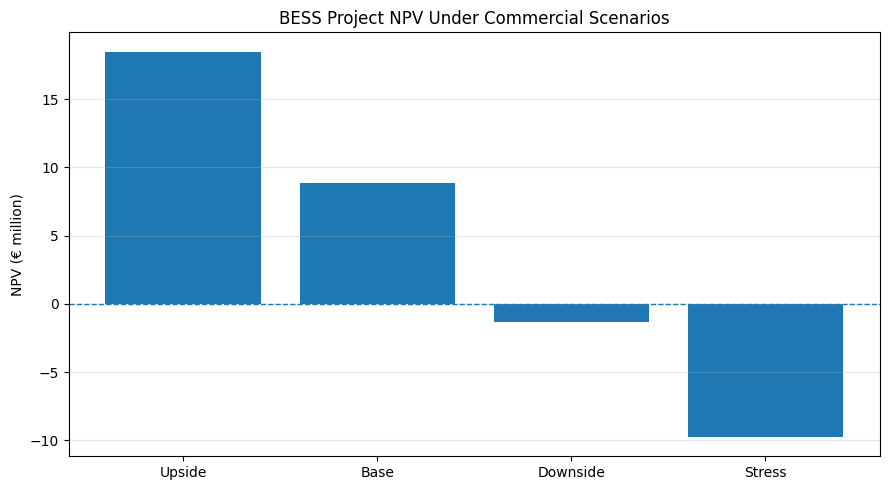

In [34]:
# Scenario NPV comparison

plt.figure(figsize=(9, 5))

plt.bar(
    scenario_results["scenario"],
    scenario_results["NPV_EUR"] / 1e6
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.ylabel("NPV (€ million)")
plt.title("BESS Project NPV Under Commercial Scenarios")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

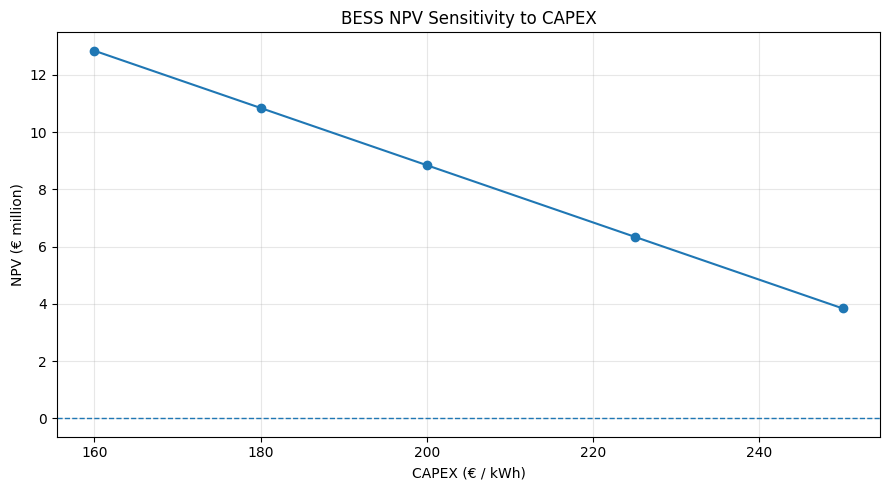

In [35]:
# NPV sensitivity to CAPEX

plt.figure(figsize=(9, 5))

plt.plot(
    capex_sensitivity["CAPEX_EUR_per_kWh"],
    capex_sensitivity["NPV_EUR"] / 1e6,
    marker="o"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("CAPEX (€ / kWh)")
plt.ylabel("NPV (€ million)")
plt.title("BESS NPV Sensitivity to CAPEX")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

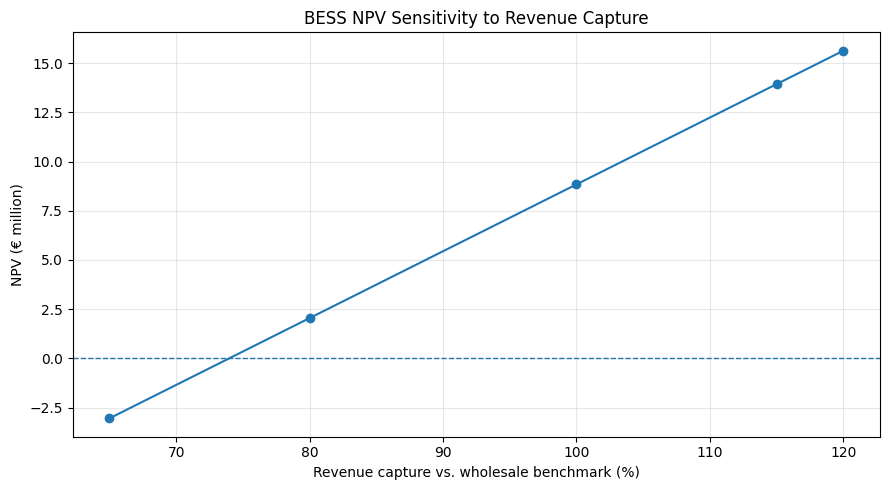

In [36]:
# NPV sensitivity to annual revenue capture

plt.figure(figsize=(9, 5))

plt.plot(
    revenue_sensitivity["revenue_multiplier"] * 100,
    revenue_sensitivity["NPV_EUR"] / 1e6,
    marker="o"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Revenue capture vs. wholesale benchmark (%)")
plt.ylabel("NPV (€ million)")
plt.title("BESS NPV Sensitivity to Revenue Capture")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
# Approximate revenue break-even point
#
# Find the annual revenue multiplier at which NPV = 0.
# This is calculated using the base CAPEX and O&M assumptions.

from scipy.optimize import brentq

def npv_for_revenue_multiplier(multiplier):

    annual_revenue = (
        annualized_wholesale_revenue
        * multiplier
    )

    operating_cash_flows = (
        annual_revenue
        * degradation_profile["capacity_factor"]
        - ANNUAL_FIXED_OM_EUR
    )

    cash_flows = np.concatenate([
        [-CAPEX_EUR],
        operating_cash_flows.to_numpy()
    ])

    periods = np.arange(len(cash_flows))

    return np.sum(
        cash_flows
        / (1 + DISCOUNT_RATE) ** periods
    )

break_even_multiplier = brentq(
    npv_for_revenue_multiplier,
    0.0,
    2.0
)

break_even_revenue = (
    annualized_wholesale_revenue
    * break_even_multiplier
)

print("Revenue break-even analysis")
print("=" * 60)
print(f"Break-even revenue multiplier: {break_even_multiplier:.2%}")
print(f"Break-even annual revenue:      €{break_even_revenue:,.0f}")
print(f"Wholesale benchmark revenue:   €{annualized_wholesale_revenue:,.0f}")
print(f"Base stacked revenue:           €{base_annual_revenue:,.0f}")

Revenue break-even analysis
Break-even revenue multiplier: 85.08%
Break-even annual revenue:      €3,386,032
Wholesale benchmark revenue:   €3,980,047
Base stacked revenue:           €4,577,054


In [38]:
# CAPEX break-even analysis
#
# Hold the base stacked revenue and base O&M constant.

def npv_for_capex_per_kwh(capex_per_kwh):

    project_capex = (
        TOTAL_CAPACITY_KWH
        * capex_per_kwh
    )

    operating_cash_flows = (
        base_annual_revenue
        * degradation_profile["capacity_factor"]
        - ANNUAL_FIXED_OM_EUR
    )

    cash_flows = np.concatenate([
        [-project_capex],
        operating_cash_flows.to_numpy()
    ])

    periods = np.arange(len(cash_flows))

    return np.sum(
        cash_flows
        / (1 + DISCOUNT_RATE) ** periods
    )

break_even_capex = brentq(
    npv_for_capex_per_kwh,
    0.0,
    1000.0
)

print("CAPEX break-even analysis")
print("=" * 60)
print(f"Maximum NPV-neutral CAPEX: €{break_even_capex:.2f}/kWh")
print(f"Base CAPEX:                €{CAPEX_EUR_PER_KWH:.2f}/kWh")
print(f"Base project CAPEX:        €{CAPEX_EUR:,.0f}")

CAPEX break-even analysis
Maximum NPV-neutral CAPEX: €288.41/kWh
Base CAPEX:                €200.00/kWh
Base project CAPEX:        €20,000,000


In [39]:
# Save commercial analysis outputs for reproducibility

SCENARIO_OUTPUT_FILE = RESULTS_DIR / "commercial_scenario_analysis.csv"
CAPEX_SENSITIVITY_FILE = RESULTS_DIR / "capex_sensitivity.csv"
REVENUE_SENSITIVITY_FILE = RESULTS_DIR / "revenue_sensitivity.csv"

scenario_results.to_csv(
    SCENARIO_OUTPUT_FILE,
    index=False
)

capex_sensitivity.to_csv(
    CAPEX_SENSITIVITY_FILE,
    index=False
)

revenue_sensitivity.to_csv(
    REVENUE_SENSITIVITY_FILE,
    index=False
)

print("Saved:")
print(SCENARIO_OUTPUT_FILE)
print(CAPEX_SENSITIVITY_FILE)
print(REVENUE_SENSITIVITY_FILE)

Saved:
C:\Users\USER\dutch-bess-market-commercial-optimization\results\commercial_scenario_analysis.csv
C:\Users\USER\dutch-bess-market-commercial-optimization\results\capex_sensitivity.csv
C:\Users\USER\dutch-bess-market-commercial-optimization\results\revenue_sensitivity.csv


In [40]:
# Final commercial KPIs
#
# These values are taken from the consistent Base scenario
# valuation framework developed later in the notebook.

base_scenario_row = scenario_results[
    scenario_results["scenario"] == "Base"
].iloc[0]

commercial_kpis = pd.Series({
    "CAPEX_EUR": base_scenario_row["CAPEX_EUR"],
    "Annual_Fixed_O&M_EUR": base_scenario_row["annual_om_eur"],
    "Annualized_Wholesale_Revenue_EUR": annualized_wholesale_revenue,
    "Base_Balancing_Uplift": BALANCING_REVENUE_UPLIFT_BASE,
    "Base_Annual_Gross_Revenue_EUR": base_scenario_row["annual_revenue_eur"],
    "NPV_EUR": base_scenario_row["NPV_EUR"],
    "IRR": base_scenario_row["IRR"],
    "Simple_Payback_Years": base_scenario_row["simple_payback_years"],
})

display(commercial_kpis.round(2))

CAPEX_EUR                           20000000.00
Annual_Fixed_O&M_EUR                  600000.00
Annualized_Wholesale_Revenue_EUR     3980046.82
Base_Balancing_Uplift                      0.15
Base_Annual_Gross_Revenue_EUR        4577053.85
NPV_EUR                              8841364.67
IRR                                        0.15
Simple_Payback_Years                       5.54
dtype: float64

In [41]:
# Commercial structure comparison

commercial_structures = pd.DataFrame({
    "structure": [
        "Merchant",
        "Tolling / Contracted",
        "Revenue Floor",
        "Hybrid",
    ],
    "revenue_risk": [
        "High",
        "Low",
        "Medium",
        "Medium",
    ],
    "upside_capture": [
        "High",
        "Low",
        "Medium-High",
        "High",
    ],
    "financing_visibility": [
        "Lower",
        "Higher",
        "Medium",
        "Medium-High",
    ],
    "main_value_driver": [
        "Market spreads and balancing opportunity",
        "Contracted availability / fixed payments",
        "Downside protection",
        "Combination of contracted floor and merchant upside",
    ],
})

display(commercial_structures)

,structure,revenue_risk,upside_capture,financing_visibility,main_value_driver
0,Merchant,High,High,Lower,Market spreads and balancing opportunity
1,Tolling / Contracted,Low,Low,Higher,Contracted availability / fixed payments
2,Revenue Floor,Medium,Medium-High,Medium,Downside protection
3,Hybrid,Medium,High,Medium-High,Combination of contracted floor and merchant u...


In [42]:
print("Commercial interpretation")
print("=" * 70)

print(
    f"1. The historical wholesale benchmark generates approximately "
    f"€{annualized_wholesale_revenue:,.0f} per year."
)

print(
    f"2. A 15% balancing uplift increases the base stacked revenue "
    f"to approximately €{base_annual_revenue:,.0f} per year."
)

print(
    f"3. Under the modeled Base scenario, project NPV is approximately "
    f"€{base_scenario_row['NPV_EUR']:,.0f}, with an IRR of "
    f"{base_scenario_row['IRR']:.2%}."
)

print(
    f"4. NPV becomes approximately zero at an annual revenue level "
    f"of €{break_even_revenue:,.0f}."
)

print(
    f"5. At the base revenue assumption, the project can tolerate "
    f"approximately €{break_even_capex:.0f}/kWh CAPEX before NPV "
    f"reaches zero."
)

print(
    "6. The project therefore has meaningful value under the Base case, "
    "but downside revenue capture can materially erode project economics."
)

Commercial interpretation
1. The historical wholesale benchmark generates approximately €3,980,047 per year.
2. A 15% balancing uplift increases the base stacked revenue to approximately €4,577,054 per year.
3. Under the modeled Base scenario, project NPV is approximately €8,841,365, with an IRR of 15.13%.
4. NPV becomes approximately zero at an annual revenue level of €3,386,032.
5. At the base revenue assumption, the project can tolerate approximately €288/kWh CAPEX before NPV reaches zero.
6. The project therefore has meaningful value under the Base case, but downside revenue capture can materially erode project economics.


In [43]:
# Final investment conclusion

print("FINAL BESS COMMERCIAL CONCLUSION")
print("=" * 70)

print(
    "The analysis indicates that a 50 MW / 100 MWh BESS can capture "
    "meaningful value from Dutch wholesale price volatility under "
    "historical perfect-foresight conditions."
)

print(
    f"The optimized wholesale benchmark produces approximately "
    f"€{annualized_wholesale_revenue:,.0f} of annualized revenue, "
    f"before the modeled balancing uplift."
)

print(
    f"Adding a simplified 15% balancing revenue uplift gives a "
    f"Base stacked revenue assumption of approximately "
    f"€{base_annual_revenue:,.0f} per year."
)

print(
    f"Under the Base commercial scenario, the modeled project has "
    f"approximately €{base_scenario_row['NPV_EUR']:,.0f} NPV and "
    f"{base_scenario_row['IRR']:.2%} IRR."
)

print(
    "However, the downside and stress cases demonstrate that "
    "BESS economics remain highly dependent on achievable revenue "
    "capture, market conditions and installed CAPEX."
)

print(
    "The key commercial question is therefore not simply whether "
    "price spreads exist, but whether sufficient value can be "
    "captured across markets while respecting battery constraints, "
    "degradation and opportunity cost."
)

print(
    "Historical perfect foresight should be interpreted as an "
    "upper-bound market opportunity benchmark rather than a "
    "real-time trading forecast."
)

FINAL BESS COMMERCIAL CONCLUSION
The analysis indicates that a 50 MW / 100 MWh BESS can capture meaningful value from Dutch wholesale price volatility under historical perfect-foresight conditions.
The optimized wholesale benchmark produces approximately €3,980,047 of annualized revenue, before the modeled balancing uplift.
Adding a simplified 15% balancing revenue uplift gives a Base stacked revenue assumption of approximately €4,577,054 per year.
Under the Base commercial scenario, the modeled project has approximately €8,841,365 NPV and 15.13% IRR.
However, the downside and stress cases demonstrate that BESS economics remain highly dependent on achievable revenue capture, market conditions and installed CAPEX.
The key commercial question is therefore not simply whether price spreads exist, but whether sufficient value can be captured across markets while respecting battery constraints, degradation and opportunity cost.
Historical perfect foresight should be interpreted as an upper-b

In [45]:
# Prepare final KPI table for export

final_kpis = commercial_kpis

print("Final KPI values ready for export:")
display(final_kpis)

Final KPI values ready for export:


CAPEX_EUR                           2.000000e+07
Annual_Fixed_O&M_EUR                6.000000e+05
Annualized_Wholesale_Revenue_EUR    3.980047e+06
Base_Balancing_Uplift               1.500000e-01
Base_Annual_Gross_Revenue_EUR       4.577054e+06
NPV_EUR                             8.841365e+06
IRR                                 1.513034e-01
Simple_Payback_Years                5.540058e+00
dtype: float64

In [46]:
# Save final commercial KPI output

FINAL_KPI_FILE = RESULTS_DIR / "final_commercial_kpis.csv"

final_kpis.to_csv(
    FINAL_KPI_FILE,
    header=["value"]
)

print("Saved final KPI file:")
print(FINAL_KPI_FILE)

Saved final KPI file:
C:\Users\USER\dutch-bess-market-commercial-optimization\results\final_commercial_kpis.csv


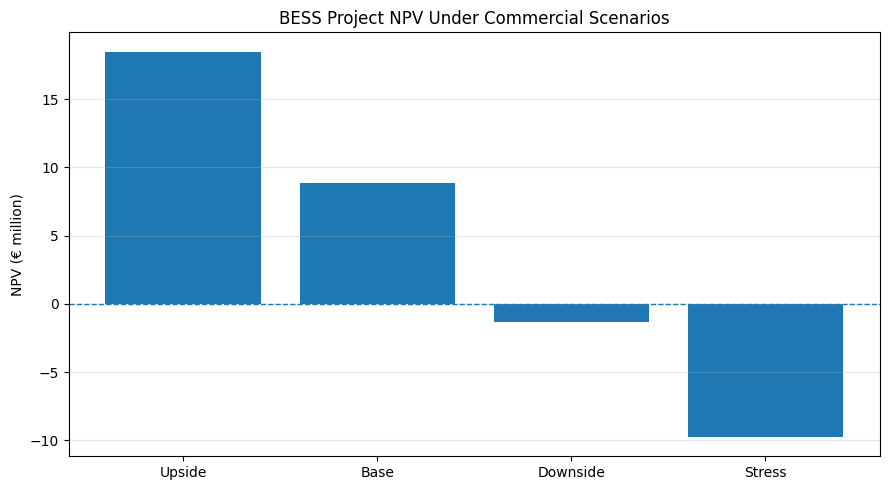

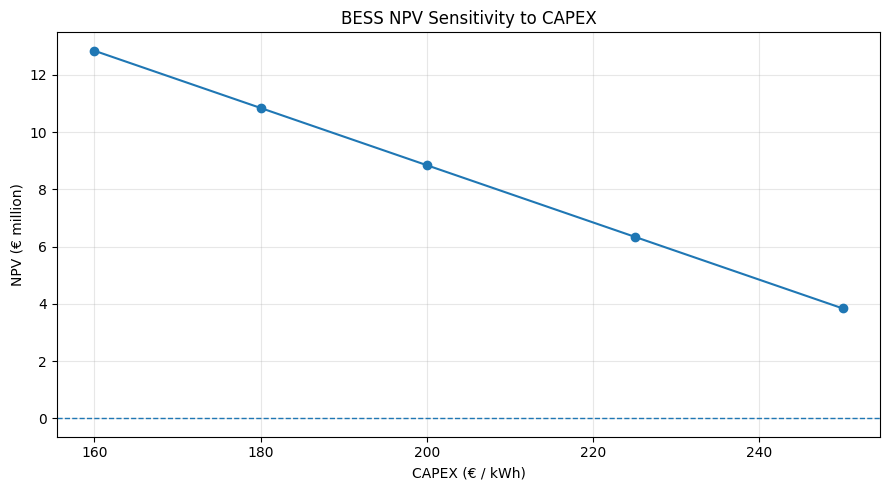

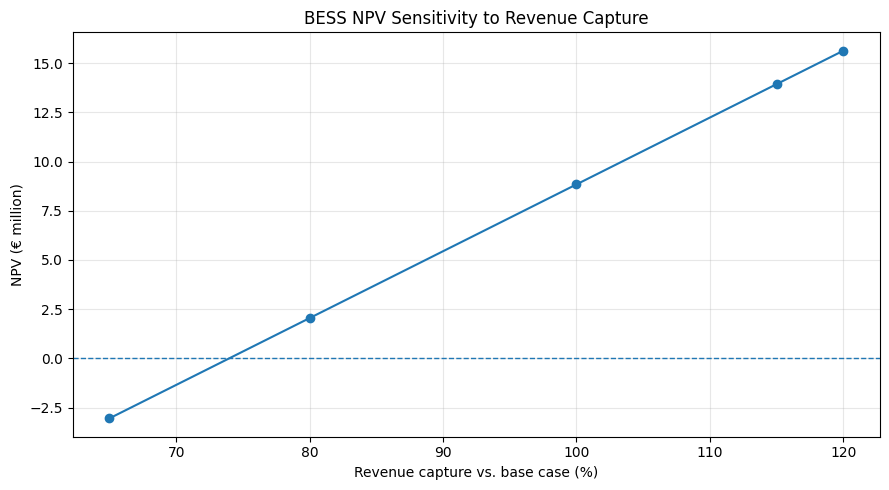

Commercial figures saved successfully.
C:\Users\USER\dutch-bess-market-commercial-optimization\figures


In [47]:
# Save final commercial charts for the portfolio

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# 1. Scenario NPV
plt.figure(figsize=(9, 5))
plt.bar(
    scenario_results["scenario"],
    scenario_results["NPV_EUR"] / 1e6
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel("NPV (€ million)")
plt.title("BESS Project NPV Under Commercial Scenarios")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "commercial_scenario_npv.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()
plt.close()


# 2. CAPEX sensitivity
plt.figure(figsize=(9, 5))
plt.plot(
    capex_sensitivity["CAPEX_EUR_per_kWh"],
    capex_sensitivity["NPV_EUR"] / 1e6,
    marker="o"
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("CAPEX (€ / kWh)")
plt.ylabel("NPV (€ million)")
plt.title("BESS NPV Sensitivity to CAPEX")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "capex_sensitivity_npv.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()
plt.close()


# 3. Revenue sensitivity
plt.figure(figsize=(9, 5))
plt.plot(
    revenue_sensitivity["revenue_multiplier"] * 100,
    revenue_sensitivity["NPV_EUR"] / 1e6,
    marker="o"
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Revenue capture vs. base case (%)")
plt.ylabel("NPV (€ million)")
plt.title("BESS NPV Sensitivity to Revenue Capture")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "revenue_sensitivity_npv.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()
plt.close()

print("Commercial figures saved successfully.")
print(FIGURES_DIR)

In [48]:
# Final results inventory

print("FIGURES")
print("=" * 60)

for file in sorted(FIGURES_DIR.glob("*")):
    print(file.name)

print("\nRESULTS")
print("=" * 60)

for file in sorted(RESULTS_DIR.glob("*")):
    print(file.name)

FIGURES
capex_sensitivity_npv.png
commercial_scenario_npv.png
june_2026_bess_dispatch_example.png
monthly_bess_efc.png
monthly_wholesale_arbitrage_revenue.png
revenue_sensitivity_npv.png

RESULTS
capex_sensitivity.csv
commercial_scenario_analysis.csv
final_commercial_kpis.csv
monthly_bess_arbitrage_full_history.csv
monthly_bess_arbitrage_scenarios.csv
revenue_sensitivity.csv
